In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Zadanie 1 - kNN na Iris

"""
Wytrenuj klasyfikator kNN na datasecie Iris z k=3.

Wymagania:
Podziel dane na train/test (80/20) ze stratyfikacja
Zastosuj standaryzacje (StandardScaler)
Oblicz accuracy, precision, recall na zbiorze testowym
Wyswietl confusion matrix

Oczekiwany wynik:
Raport klasyfikacji i macierz pomylek
"""

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, \
    roc_auc_score

# writing data
data = load_iris()
X = data.data
y = data.target

# train & test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# standarization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# kNN training
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

# prediction
y_pred = knn.predict(X_test_scaled)

# calculating accuracy, precision and recall on test set
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# classification report
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# confusion matrix
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9333
Precision: 0.9444
Recall: 0.9333

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


Confusion matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


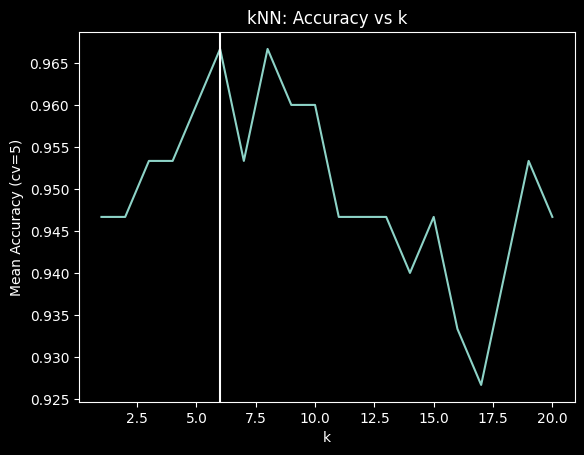

Optymalne k: 6


In [1]:
# Zadanie 2 - Wybor k dla kNN
"""
Przetestuj wartosci k od 1 do 20 na datasecie Iris z walidacja krzyzowa (cv=5).

Wymagania:
Oblicz srednia accuracy dla kazdego k
Narysuj wykres accuracy vs k
Wskaż optymalna wartosc k

Oczekiwany wynik:
Wykres z zaznaczonym optymalnym k
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X, y = iris.data, iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = range(1, 21)
mean_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring="accuracy")
    mean_accuracies.append(scores.mean())

optimal_k = k_values[np.argmax(mean_accuracies)]

plt.figure()
plt.plot(k_values, mean_accuracies)
plt.axvline(optimal_k)
plt.xlabel("k")
plt.ylabel("Mean Accuracy (cv=5)")
plt.title("kNN: Accuracy vs k")
plt.show()

print("Optymalne k:", optimal_k)

In [ ]:
# Zadanie 3 - SVM liniowy na Breast Cancer
"""
Wytrenuj SVM z jadrem liniowym na datasecie Breast Cancer.

Wymagania:
Standaryzacja danych
Oblicz accuracy, precision, recall, F1
Wyswietl liczbe wektorow nosnych

Oczekiwany wynik:
Raport klasyfikacji z informacja o support vectors
"""

from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm = SVC(kernel="linear")
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print(classification_report(y_test, y_pred))
print("Liczba wektorów nośnych:", svm.n_support_)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- class: 2
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: 2



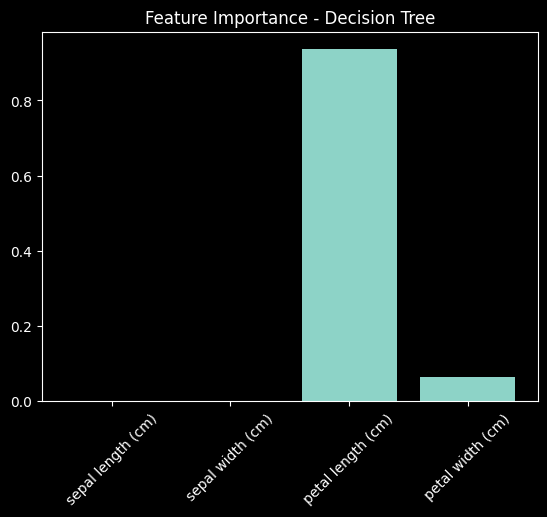

In [7]:
# Zadanie 4 - Drzewo decyzyjne na Iris
"""
Zbuduj drzewo decyzyjne na datasecie Iris z max_depth=4.

Wymagania:
Wytrenuj model BEZ standaryzacji
Wyswietl strukture drzewa jako tekst (export_text)
Narysuj wykres feature importance

Oczekiwany wynik:
Reguly drzewa i wykres waznosci cech
"""

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_text
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

print(export_text(tree, feature_names=list(iris.feature_names)))

importances = tree.feature_importances_

plt.figure()
plt.bar(iris.feature_names, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance - Decision Tree")
plt.show()

In [11]:
# Zadanie 5 - Random Forest baseline
"""
Wytrenuj Random Forest z domyslnymi parametrami na Breast Cancer.

Wymagania:
n_estimators=100, random_state=42
Oblicz accuracy, AUC
Porownaj z Logistic Regression

Oczekiwany wynik:
Porownanie dwoch modeli
"""

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train, y_train)

log_pred = logreg.predict(X_test)
log_proba = logreg.predict_proba(X_test)

log_acc = accuracy_score(y_test, y_pred)
log_auc = roc_auc_score(y_test, log_proba)

print("Random Forest - Accuracy:", rf_acc, "AUC:", rf_auc)
print("Logistic Regression - Accuracy:", log_acc, "AUC:", log_auc)

ValueError: y should be a 1d array, got an array of shape (114, 2) instead.

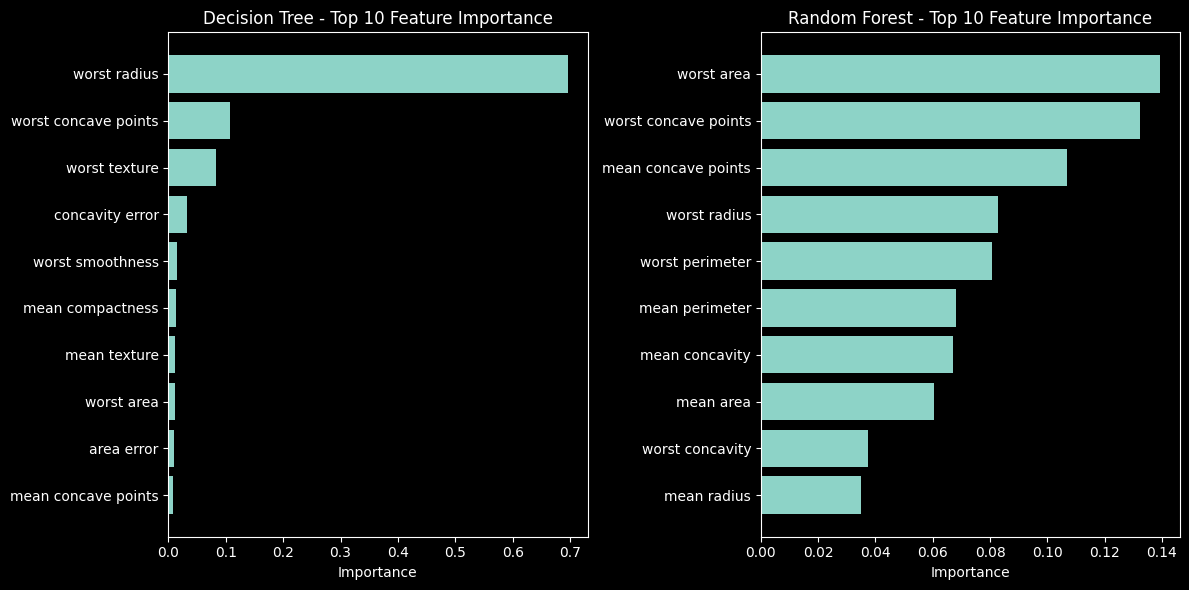

In [2]:
# Zadanie 6 - Feature Importance
"""
Porownaj feature importance z drzewa decyzyjnego i Random Forest na Breast Cancer.

Wymagania:
Wytrenuj oba modele
Narysuj wykres z Top 10 cech dla kazdego modelu (obok siebie)
Opisz roznice

Oczekiwany wynik:
Podwojny wykres barh z waznoscia cech

"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# data writing
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names


# models training
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

dt_model.fit(X, y)
rf_model.fit(X, y)

# feature importance
dt_importance = dt_model.feature_importances_
rf_importance = rf_model.feature_importances_

# top 10 features
top10_dt_idx = np.argsort(dt_importance)[-10:]
top10_rf_idx = np.argsort(rf_importance)[-10:]

dt_features = feature_names[top10_dt_idx]
rf_features = feature_names[top10_rf_idx]

dt_values = dt_importance[top10_dt_idx]
rf_values = rf_importance[top10_rf_idx]

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].barh(dt_features, dt_values)
axes[0].set_title("Decision Tree - Top 10 Feature Importance")
axes[0].set_xlabel("Importance")

axes[1].barh(rf_features, rf_values)
axes[1].set_title("Random Forest - Top 10 Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [ ]:
# Zadanie 7 - Gradient Boosting baseline
"""
Wytrenuj GradientBoostingClassifier na Breast Cancer.

Wymagania:
n_estimators=100, learning_rate=0.1, max_depth=3
Oblicz accuracy, AUC
Zmierz czas treningu (time.time())

Oczekiwany wynik:
Metryki i czas treningu
"""

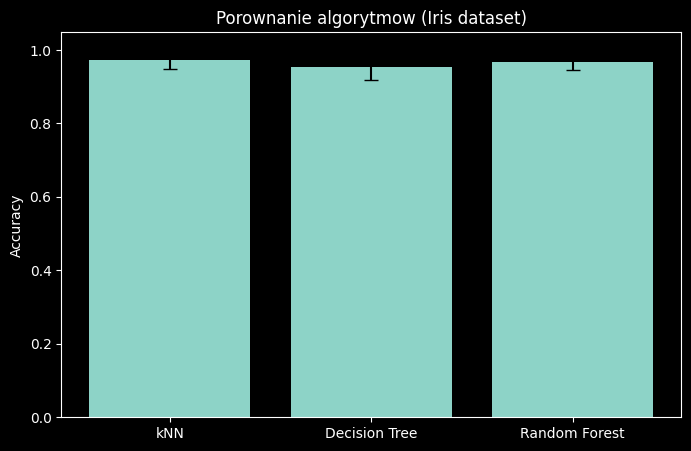


Accuracy z walidacji krzyzowej (cv=5):
kNN: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Decision Tree: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Random Forest: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Najlepszy algorytm: kNN
Accuracy: 0.9733333333333334


In [5]:
# Zadanie 8 - Porownanie 3 algorytmow
"""
Porownaj kNN, Decision Tree i Random Forest na datasecie Iris.

Wymagania:
Walidacja krzyzowa (cv=5) dla kazdego
Narysuj bar chart ze srednia accuracy i odchyleniem standardowym
Wskaż najlepszy algorytm

Oczekiwany wynik:
Wykres porownawczy z errorbar
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# data writing
data = load_iris()
X = data.data
y = data.target

# model definition
models = {
    "kNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

means = []
stds = []
names = []
all_scores = {}

# cross validation
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

    means.append(scores.mean())
    stds.append(scores.std())
    names.append(name)
    all_scores[name] = scores

# plot
plt.figure(figsize=(8,5))

plt.bar(names, means, yerr=stds, capsize=5)

plt.ylabel("Accuracy")
plt.title("Porownanie algorytmow (Iris dataset)")

plt.show()

# all accuracies
print("\nAccuracy z walidacji krzyzowej (cv=5):")
for name, scores in all_scores.items():
    print(f"{name}: {scores}")

# best model
best_index = np.argmax(means)
print("Najlepszy algorytm:", names[best_index])
print("Accuracy:", means[best_index])

In [ ]:
# Zadanie 9 - Optymalizacja SVM
"""
Znajdz optymalne parametry SVM (kernel, C, gamma) na Breast Cancer.

Dataset:
sklearn.datasets.load_breast_cancer()

Wymagania:
Przetestuj kernele: linear, rbf, poly
Dla RBF: przetestuj C = [0.1, 1, 10, 100] i gamma = ['scale', 'auto', 0.01, 0.1]
Uzyj GridSearchCV z cv=5
Wyswietl najlepsze parametry i wynik na zbiorze testowym

Oczekiwany wynik:
Najlepsze parametry, accuracy, confusion matrix
"""



In [ ]:
# Zadanie 10 - Overfitting w drzewach
"""
Zbadaj overfitting w drzewach decyzyjnych na Breast Cancer.

Wymagania:
Wytrenuj drzewa z max_depth od 1 do 20
Narysuj learning curves (train vs test accuracy) w funkcji max_depth
Dodaj wyniki Random Forest (100 drzew) jako linie pozioma
Okresl optymalna glebokosc

Oczekiwany wynik:
Wykres z zaznaczona optymalna glebokoscia i linia RF
"""

In [ ]:
# Zadanie 11 - Ensemble na Wine Quality
"""
Porownaj Random Forest, Gradient Boosting i XGBoost na datasecie Wine Quality.

Dataset:
https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv

Wymagania:
Wczytaj dane, uzyj 'quality' jako target (binaryzacja: quality >= 7 = "good", < 7 = "not
good")
Porownaj 3 modele z walidacja krzyzowa
Narysuj krzywe ROC na jednym wykresie
Zmierz czas treningu kazdego modelu

Oczekiwany wynik:
Krzywe ROC, tabela metryk i czasow
"""

In [ ]:
# Zadanie 12 - Tuning Random Forest
"""
Przeprowadz tuning hiperparametrow Random Forest na Breast Cancer.

Wymagania:
Uzyj RandomizedSearchCV z n_iter=30
Przestrzen parametrow: n_estimators (50-300), max_depth (3-20), min_samples_split
(2-20), min_samples_leaf (1-10)
Porownaj domyslny RF vs zoptymalizowany RF
Wyswietl najlepsze parametry

Oczekiwany wynik:
Porownanie accuracy: domyslny vs zoptymalizowany
"""

In [ ]:
# Zadanie 13 - Pelny benchmark algorytmow
"""
Stworz kompletny benchmark 6 algorytmow na 3 datasetach.

Datasety:
Iris (wieloklasowa klasyfikacja)
Breast Cancer (binarna klasyfikacja)
Wine (wieloklasowa klasyfikacja -- load_wine())

Wymagania:
Algorytmy: kNN, SVM, Decision Tree, Random Forest, Gradient Boosting, Logistic
Regression
Dla kazdego: walidacja krzyzowa (cv=5), accuracy, czas treningu
Stwórz tabele wynikow (DataFrame)
Narysuj heatmape z wynikami (algorytmy x datasety)
Wskaż najlepszy algorytm per dataset

Oczekiwany wynik:
Heatmapa porownawcza i analiza wynikow

"""